In [1]:
import os
import torch
import torchvision
from torch.utils.data import DataLoader
import random
import sys
from pathlib import Path

import annoy
import json

# Make imports and file paths robust whether notebook is run from repo root or notebooks/
repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt

import torch
import numpy as np
from sklearn.decomposition import PCA
from tqdm import tqdm

from torchvision import transforms
from src.models.VAE import ConvVAE, load_checkpoint


random.seed(73)
torch.manual_seed(73)
CELEBA_MEAN = [0.5, 0.5, 0.5]
CELEBA_STD  = [0.5, 0.5, 0.5]

data_root = repo_root / "local_datasets" / "celeba"
image_size = 64
LATENT_DIM = 128    # dimension of latent z  (replaces 64*64*3 in the pixel-space notebook)

celeba_data = torchvision.datasets.ImageFolder(root=str(data_root), transform=transforms.Compose([
                                  transforms.Resize(image_size),
                                  transforms.CenterCrop(image_size),
                                  transforms.ToTensor(),
                                  transforms.Normalize(mean=CELEBA_MEAN,
                                                       std=CELEBA_STD)
                              ]))

celeba_loader = DataLoader(
    celeba_data, batch_size=64, shuffle=False,
    num_workers=4, pin_memory=True
)

print(celeba_data)

# Load trained VAE encoder / decoder
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = ConvVAE(in_channels=3, image_size=image_size, latent_dim=LATENT_DIM).to(device)
ckpt_path = repo_root / "data" / "output" / "models" / "vae" / "vae_celeba_epoch_020.pt"
load_checkpoint(vae, str(ckpt_path), device)
vae.eval()
print(f"VAE loaded on {device}")
print(f"Using checkpoint: {ckpt_path}")


Dataset ImageFolder
    Number of datapoints: 202599
    Root location: d:\THESIS\RandomizedSmothingmanifold\local_datasets\celeba
    StandardTransform
Transform: Compose(
               Resize(size=64, interpolation=bilinear, max_size=None, antialias=True)
               CenterCrop(size=(64, 64))
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )
Checkpoint loaded ← d:\THESIS\RandomizedSmothingmanifold\data\output\models\vae\vae_celeba_epoch_020.pt
VAE loaded on cpu
Using checkpoint: d:\THESIS\RandomizedSmothingmanifold\data\output\models\vae\vae_celeba_epoch_020.pt


## Build Latent kNN Index


In [2]:
knn_index = annoy.AnnoyIndex(LATENT_DIM, 'euclidean')
ann_path = repo_root / "notebooks" / "celeba_latent_knn_ds.ann"
idxmap_path = repo_root / "notebooks" / "celeba_latent_knn_ds_indexmap.json"

if ann_path.exists():
    knn_index.load(str(ann_path))
    if idxmap_path.exists():
        with open(idxmap_path, 'r') as f:
            name_map = json.load(f)
    else:
        name_map = {}
    print(f"Loaded existing ANN index: {ann_path}")
    print(f"Loaded index map entries: {len(name_map)}")
else:
    print("ANN index not found. Building a new index...")
    name_map = {}
    name_idx = 0
    with torch.no_grad():
        for img, name in tqdm(celeba_data, desc="Encode images to latent z for ANN"):
            z_np = vae.encode(img.unsqueeze(0).to(device))[0].squeeze(0).cpu().numpy()
            name_map[name] = name_idx
            knn_index.add_item(name_idx, z_np)
            name_idx += 1

    knn_index.build(50)
    knn_index.save(str(ann_path))
    with open(idxmap_path, 'w') as f:
        json.dump(name_map, f)
    print(f"Built and saved ANN index: {ann_path}")
    print(f"Saved index map entries: {len(name_map)}")


Loaded existing ANN index: d:\THESIS\RandomizedSmothingmanifold\notebooks\celeba_latent_knn_ds.ann
Loaded index map entries: 1


(500, 128)
(500, 128)
(500, 128)


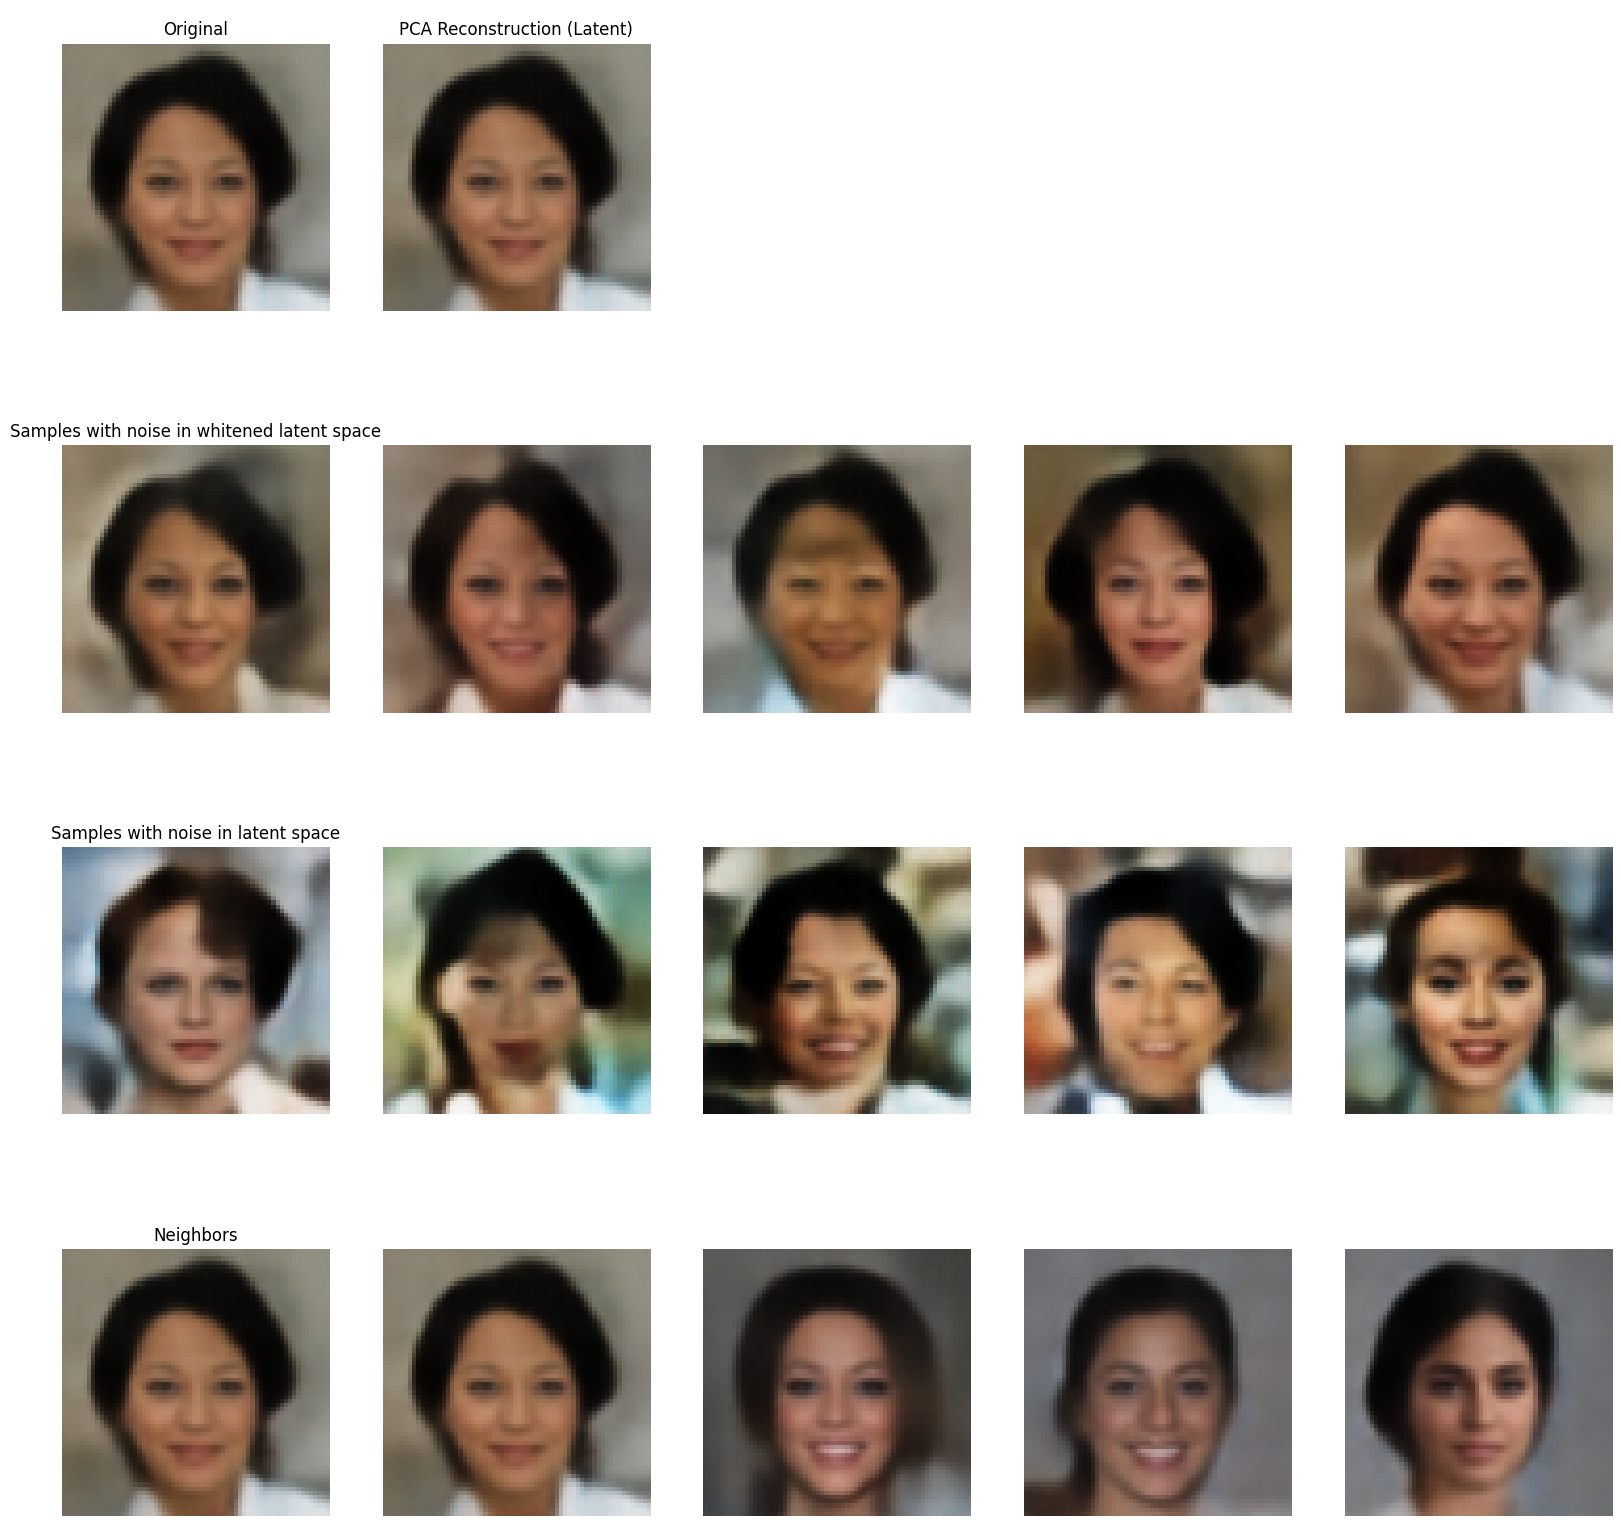

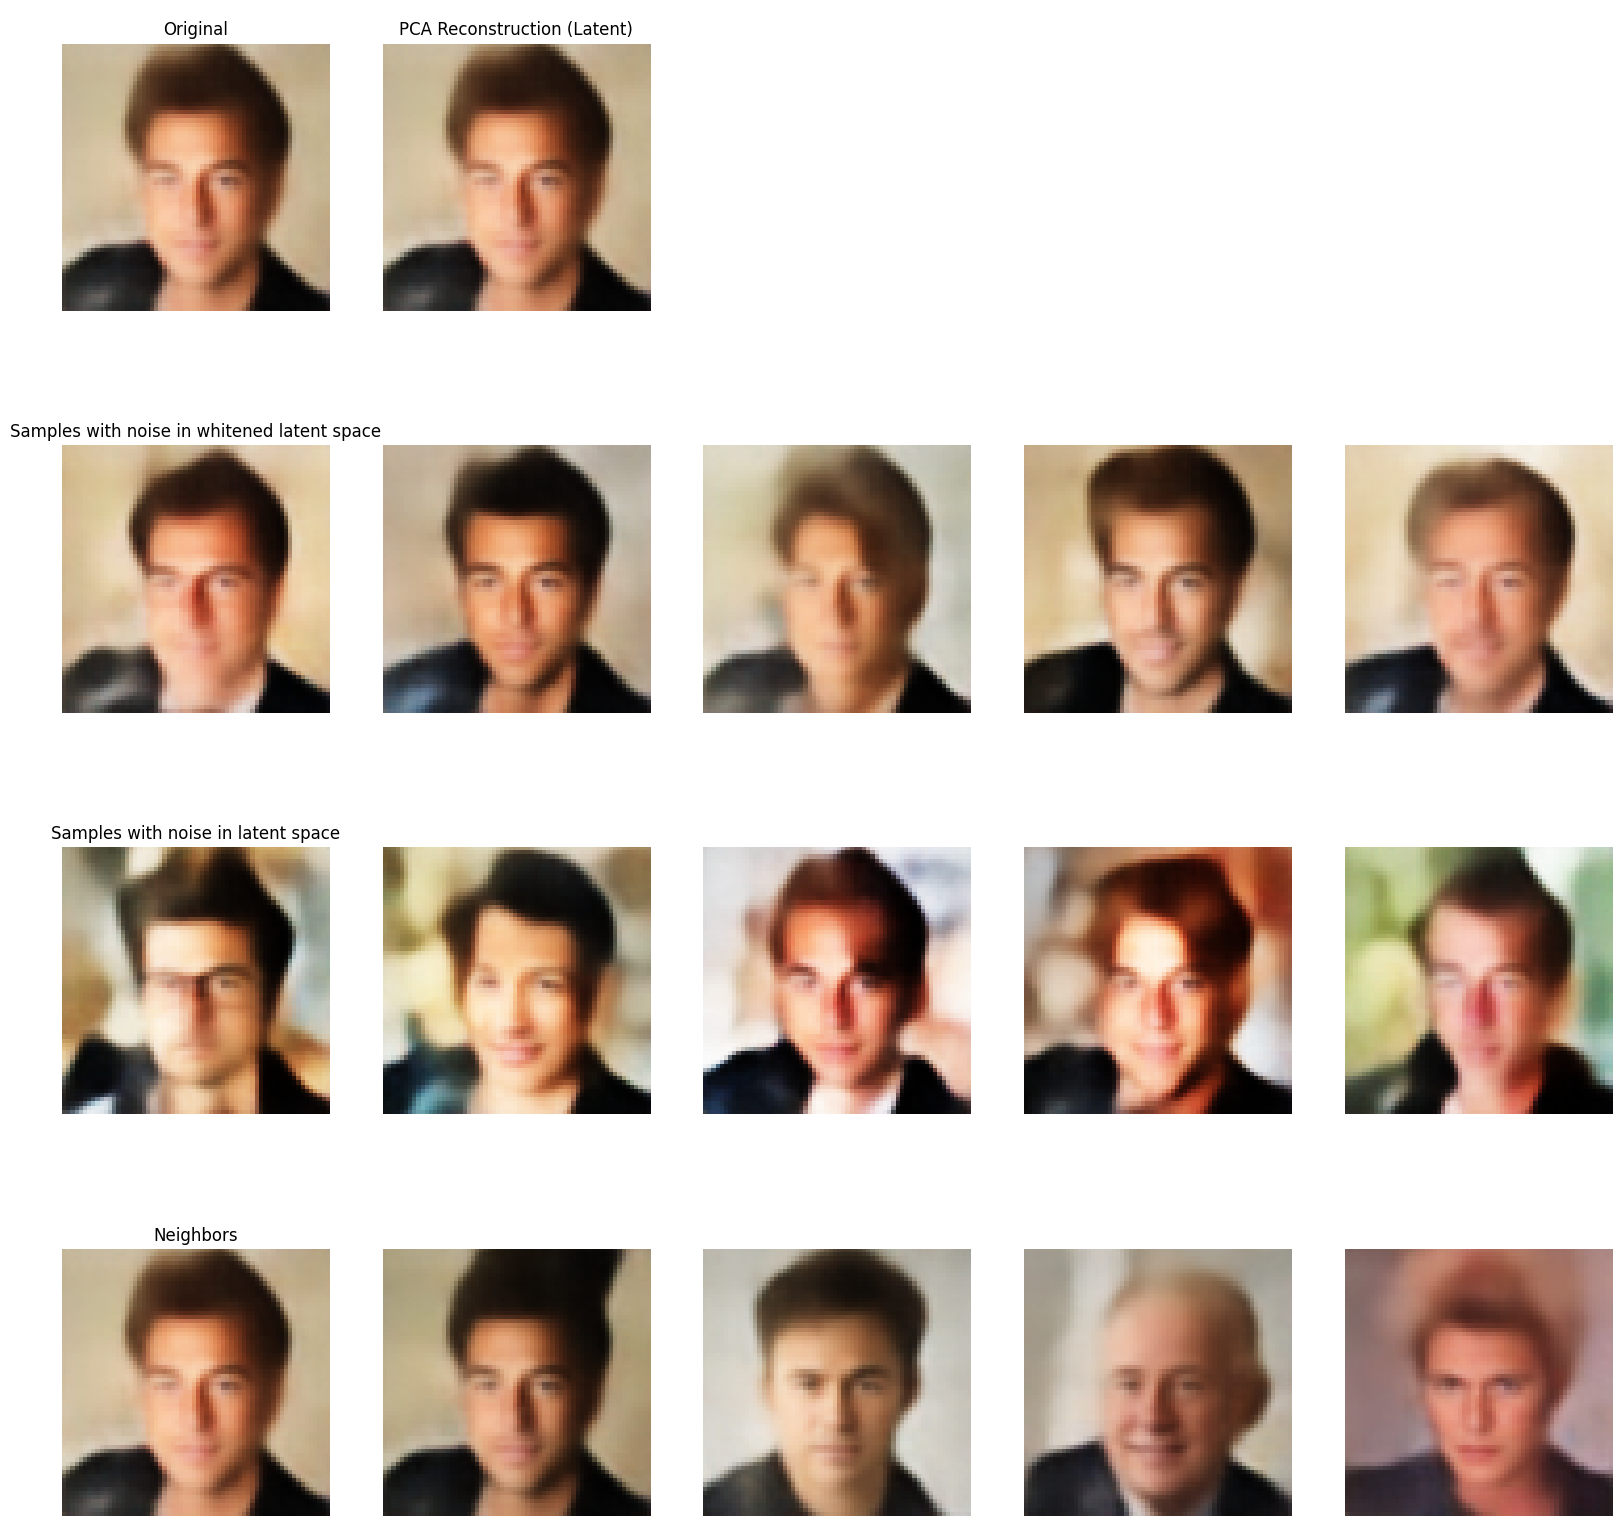

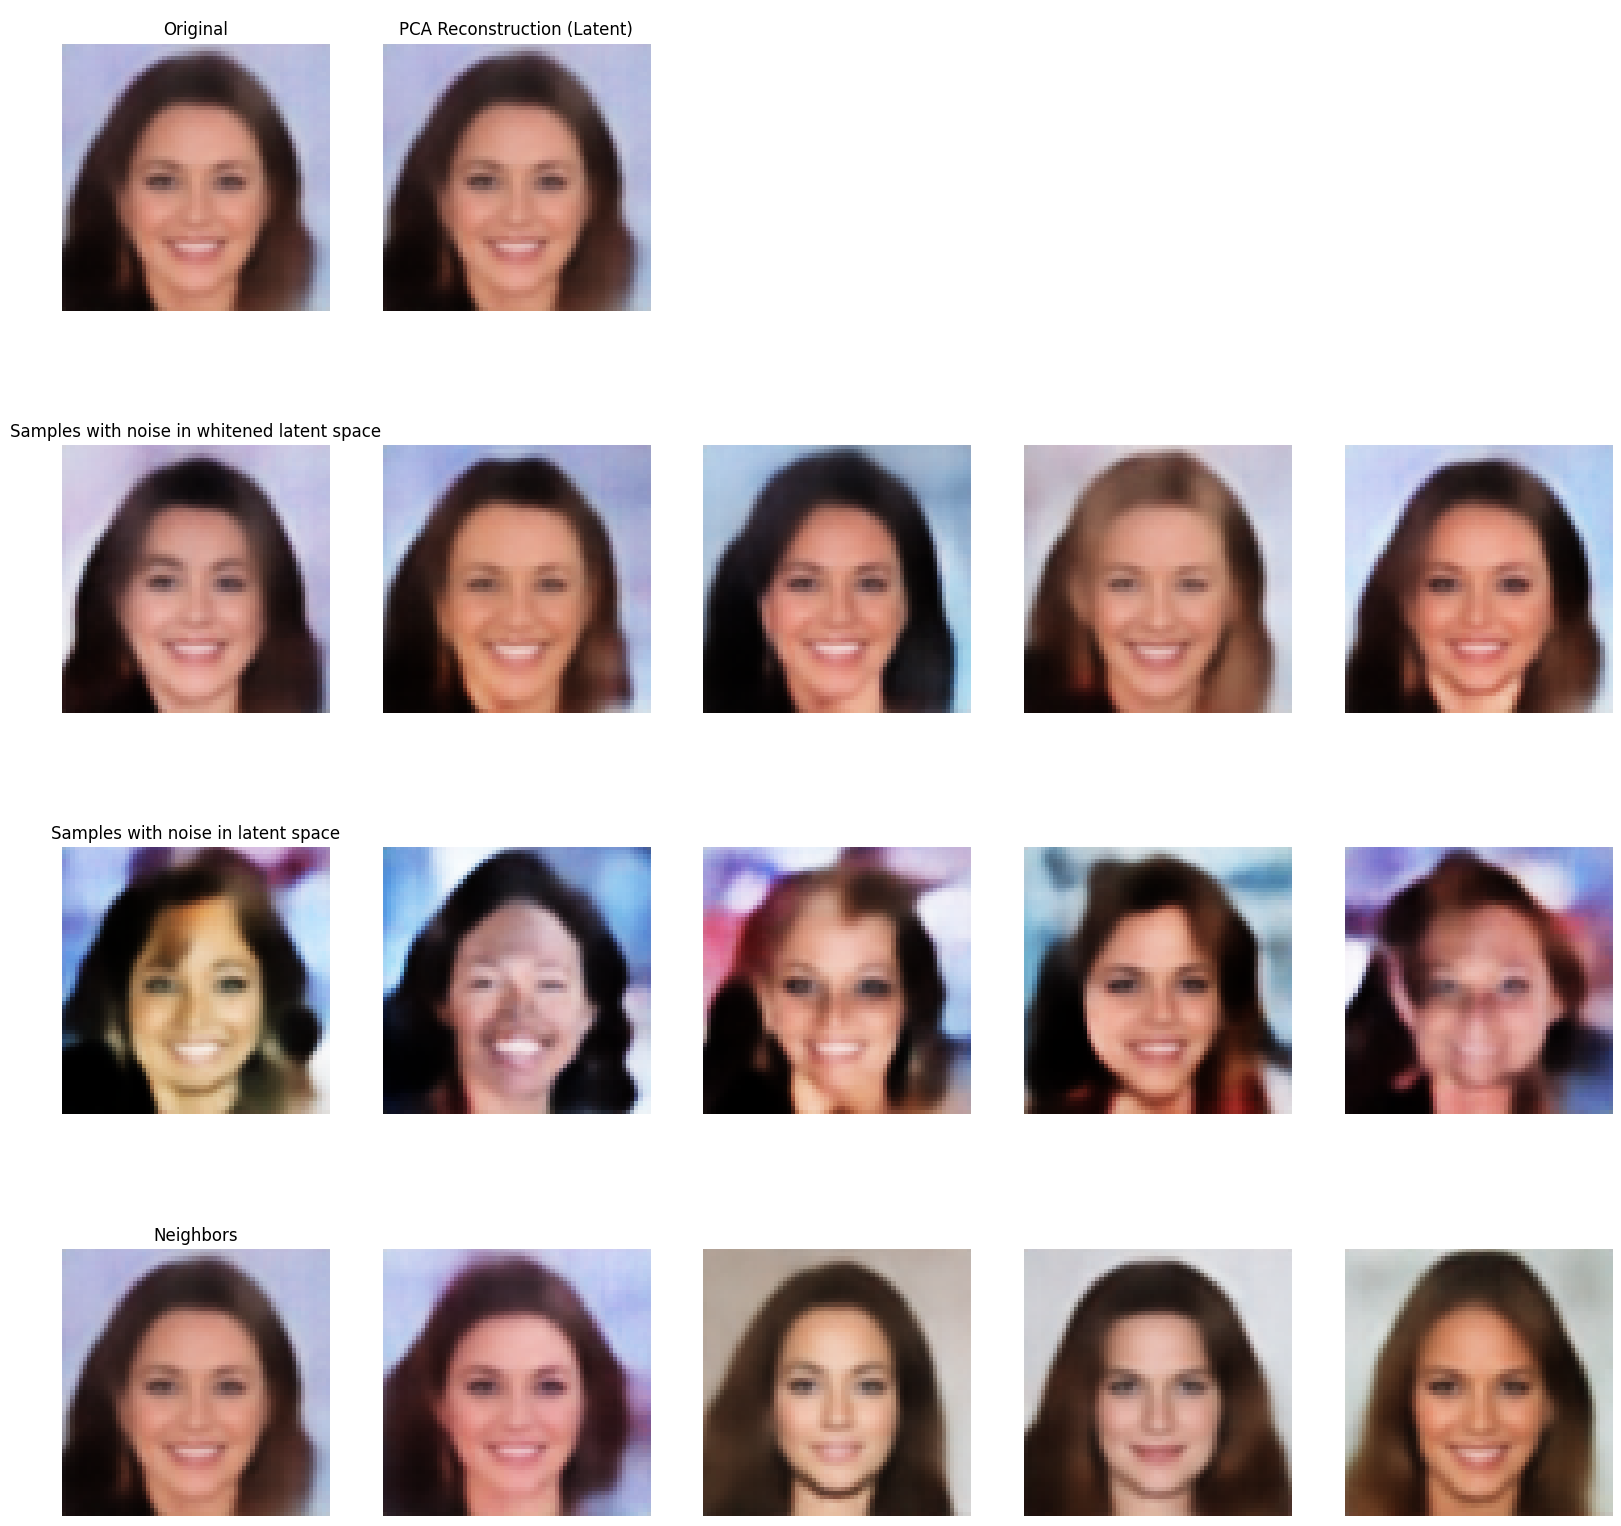

In [3]:
if 'knn_index' not in globals():
    knn_index = annoy.AnnoyIndex(LATENT_DIM, 'euclidean')
    knn_index.load(str(repo_root / "notebooks" / "celeba_latent_knn_ds.ann"))

scale_weight = 0.7  # noise std in whitened/latent space


def unnormalize_np(img):
    return np.add(np.multiply(img, CELEBA_STD), CELEBA_MEAN)


def to_latent_np(z_like):
    """Convert Annoy list or tensor-like latent vector to 1D float32 numpy array."""
    z = np.asarray(z_like, dtype=np.float32)
    if z.ndim != 1:
        z = z.reshape(-1)
    return z


def decode_z_to_img(z_np):
    """Decode a latent z vector to a displayable HWC image."""
    z_np = to_latent_np(z_np)
    with torch.no_grad():
        z_t = torch.from_numpy(z_np[None, :]).to(device=device, dtype=torch.float32)
        x_hat = vae.decode(z_t).squeeze(0).cpu().numpy()   # (C, H, W), normalized
    return unnormalize_np(np.permute_dims(x_hat, (1, 2, 0)))


def whiten_local_pca(x, mean, Vt, ev):
    """Jonas form: w = Lambda^{-1/2} U^T (x - mu).

    With sklearn PCA: rows of Vt are eigenvectors (U^T), ev are eigenvalues (Lambda diag).
    """
    x = to_latent_np(x)
    x_centered = x - mean
    return (x_centered @ Vt.T) / np.sqrt(ev)


def unwhiten_local_pca(w, mean, Vt, ev):
    """Jonas inverse: x = mu + U Lambda^{1/2} w."""
    w = to_latent_np(w)
    return mean + (w * np.sqrt(ev)) @ Vt


target_idcs = [100, 51, 42]

for target_idx in target_idcs:

    X_img, X_class = celeba_data[target_idx]
    k = 500
    X_nns_idcs = knn_index.get_nns_by_item(target_idx, k)

    X_local_n = []
    for i in X_nns_idcs:
        X_local_n.append(to_latent_np(knn_index.get_item_vector(i)))
    X_local_n = np.stack(X_local_n).astype(np.float32)
    print(X_local_n.shape)

    # Original latent vector and image
    X_orig_flat = to_latent_np(knn_index.get_item_vector(target_idx))
    orig_img = decode_z_to_img(X_orig_flat)

    # Local mean and centered neighborhood
    mean_local_n = np.mean(X_local_n, axis=0).astype(np.float32)
    X_local_centered = X_local_n - mean_local_n

    # Local PCA in latent space
    n_components = min(k, LATENT_DIM)
    pca = PCA(n_components=n_components)
    pca.fit(X_local_centered)
    ev = np.maximum(pca.explained_variance_.astype(np.float32), 1e-8)
    Vt = pca.components_.astype(np.float32)

    # Whiten and exact reconstruct (should be near lossless up to numeric error)
    X_whitened = whiten_local_pca(X_orig_flat, mean_local_n, Vt, ev)
    Z_recon = unwhiten_local_pca(X_whitened, mean_local_n, Vt, ev)
    orig_rec = decode_z_to_img(Z_recon)

    n_samples = 5
    fig, axes = plt.subplots(4, 5, figsize=(20, 20))
    for ax in axes.flat:
        ax.axis("off")

    axes[0, 0].imshow(orig_img)
    axes[0, 0].set_title("Original")
    axes[0, 0].axis("off")
    axes[0, 1].imshow(orig_rec)
    axes[0, 1].set_title("PCA Reconstruction (Latent)")
    axes[0, 1].axis("off")

    # Noisy samples: add isotropic Gaussian in whitened PCA space
    for i in range(n_samples):
        eps = np.random.normal(loc=0.0, scale=scale_weight, size=n_components).astype(np.float32)
        X_noised = X_whitened + eps

        # Unwhiten back to latent space and decode
        Z_noised = unwhiten_local_pca(X_noised, mean_local_n, Vt, ev)
        rec_img = decode_z_to_img(Z_noised)
        ax = axes[(i // 5) + 1, i % 5]
        if i == 0:
            ax.set_title("Samples with noise in whitened latent space")
        ax.imshow(rec_img)
        ax.axis("off")

    # Noisy samples: isotropic Gaussian directly in latent space
    for i in range(n_samples):
        Z_noised = X_orig_flat + np.random.normal(loc=0.0, scale=scale_weight, size=X_orig_flat.shape).astype(np.float32)
        rec_img = decode_z_to_img(Z_noised)
        ax = axes[((i + 1 * n_samples) // 5) + 1, (i + 1 * n_samples) % 5]
        if i == 0:
            ax.set_title("Samples with noise in latent space")
        ax.imshow(rec_img)
        ax.axis("off")

    for i, target_i in enumerate(X_nns_idcs[0:5]):
        Z_nn = to_latent_np(knn_index.get_item_vector(target_i))
        nn_img = decode_z_to_img(Z_nn)
        ax = axes[((i + 2 * n_samples) // 5) + 1, (i + 2 * n_samples) % 5]
        if i == 0:
            ax.set_title("Neighbors")
        ax.imshow(nn_img)
        ax.axis("off")

    scale_single_weight = scale_weight / 2

# Moving in Single PCA Direction

In [ ]:

target_idx = 100 
k = 500              # local neighborhood size
X_img, X_class = celeba_data[target_idx]

# Original latent vector from Annoy index
X_orig_flat = to_latent_np(knn_index.get_item_vector(target_idx))

# Decode original image
orig_img = decode_z_to_img(X_orig_flat)

In [9]:
# Retrieve k nearest neighbors in latent space
X_nns_idcs = knn_index.get_nns_by_item(target_idx, k)
X_local_n = []
for idx in X_nns_idcs:
    z_nn = to_latent_np(knn_index.get_item_vector(idx))
    X_local_n.append(z_nn)

X_local_n = np.stack(X_local_n).astype(np.float32)

print("Local neighborhood shape:", X_local_n.shape)

Local neighborhood shape: (500, 128)


In [10]:
#  Compute local PCA

mean_local_n = np.mean(X_local_n, axis=0).astype(np.float32)
X_local_centered = X_local_n - mean_local_n

n_components = min(k, LATENT_DIM)

pca = PCA(n_components=n_components)
pca.fit(X_local_centered)

ev = np.maximum(pca.explained_variance_.astype(np.float32), 1e-8)
Vt = pca.components_.astype(np.float32)

print("PCA components:", Vt.shape)
print("Eigenvalues:", ev[:10])

PCA components: (128, 128)
Eigenvalues: [1.850002   1.3220124  1.1783528  1.0974729  1.0059317  0.8772938
 0.84732246 0.80072737 0.68114454 0.6756944 ]


In [13]:
#  Whiten target sample
X_whitened = whiten_local_pca(
    X_orig_flat,
    mean_local_n,
    Vt,
    ev
)

# Check reconstruction
Z_recon = unwhiten_local_pca(
    X_whitened,
    mean_local_n,
    Vt,
    ev
)

orig_rec = decode_z_to_img(Z_recon)

recon_error = np.linalg.norm(X_orig_flat - Z_recon)
print("Reconstruction error:", recon_error)


Reconstruction error: 4.2015563e-06


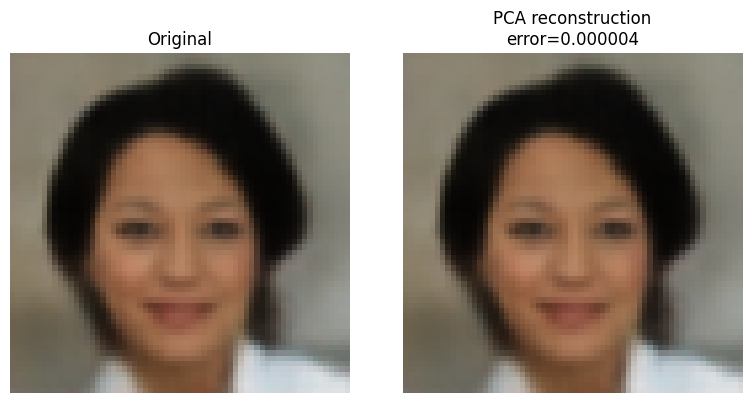

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(orig_img)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(orig_rec)
axes[1].set_title(f"PCA reconstruction\nerror={recon_error:.6f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [17]:
pcs_to_analyze = [0, 1, 2, 3, 4,5, 6, 7, 8, 9]
steps = [-3, -2, -1, 0, 1, 2, 3]

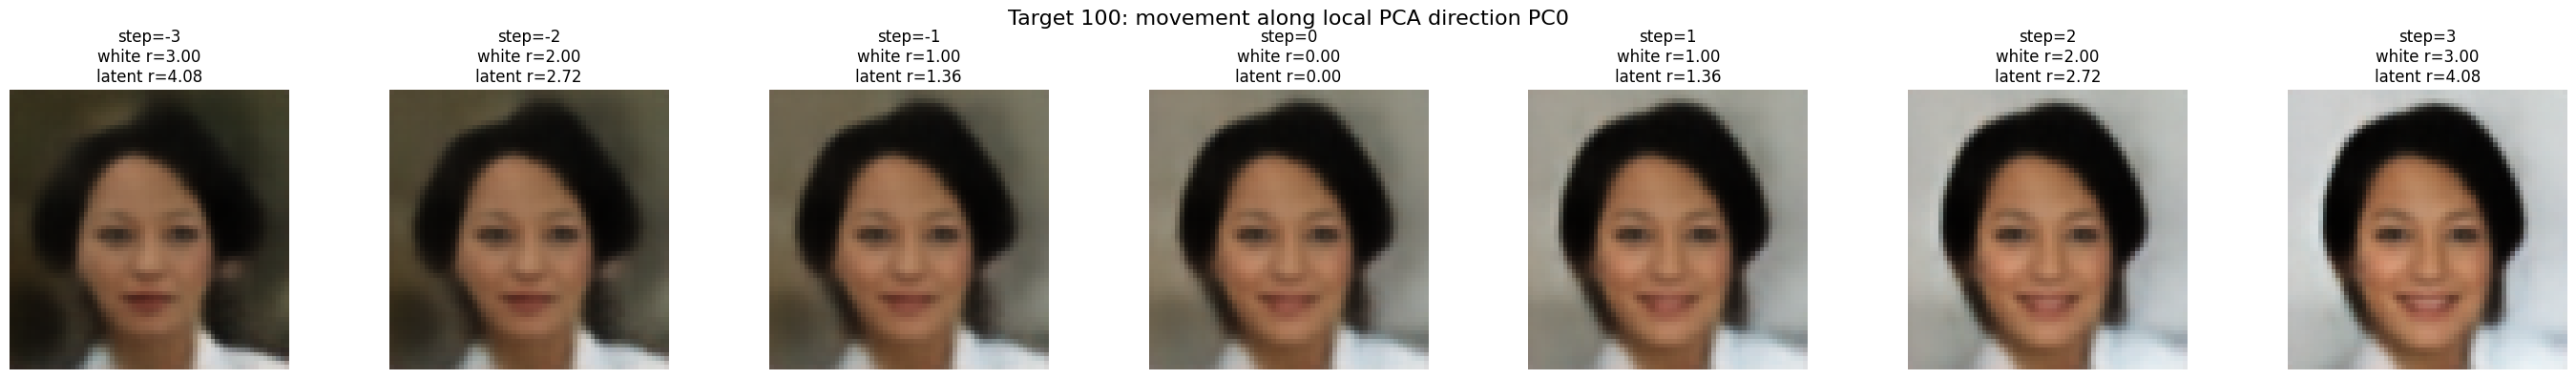

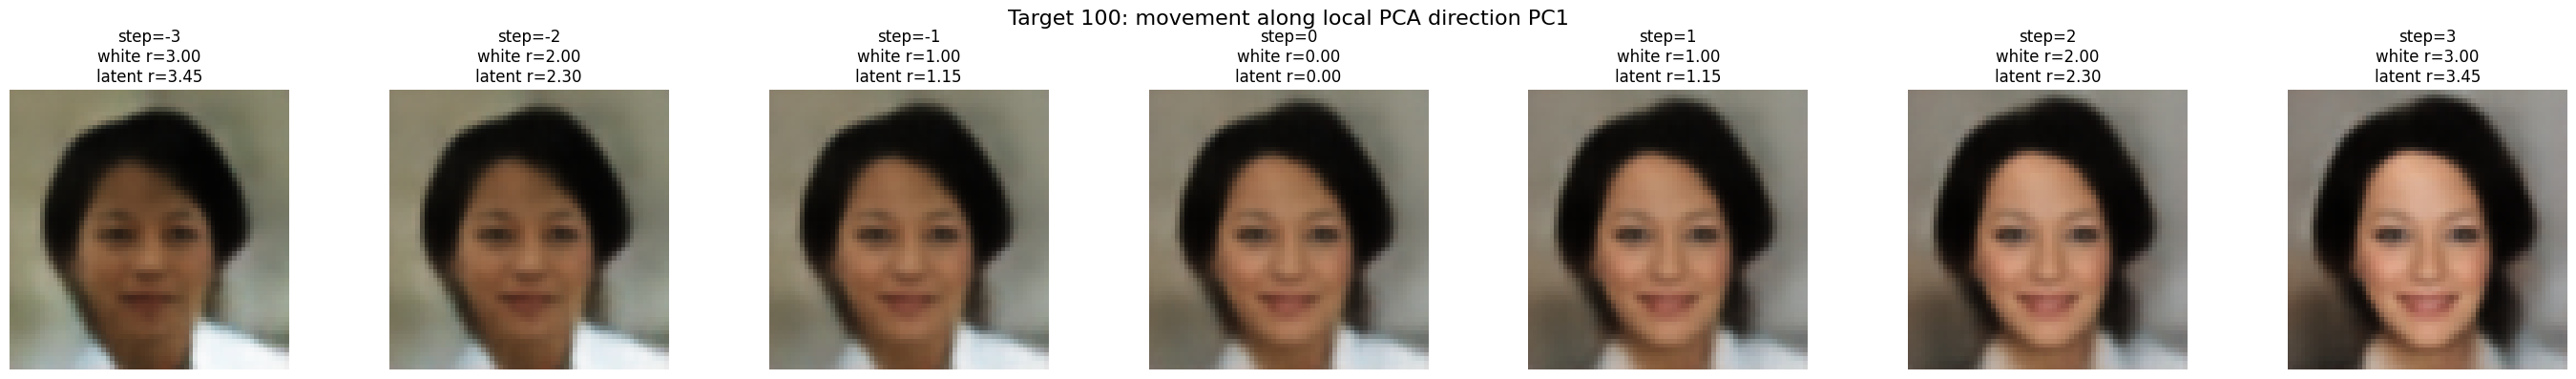

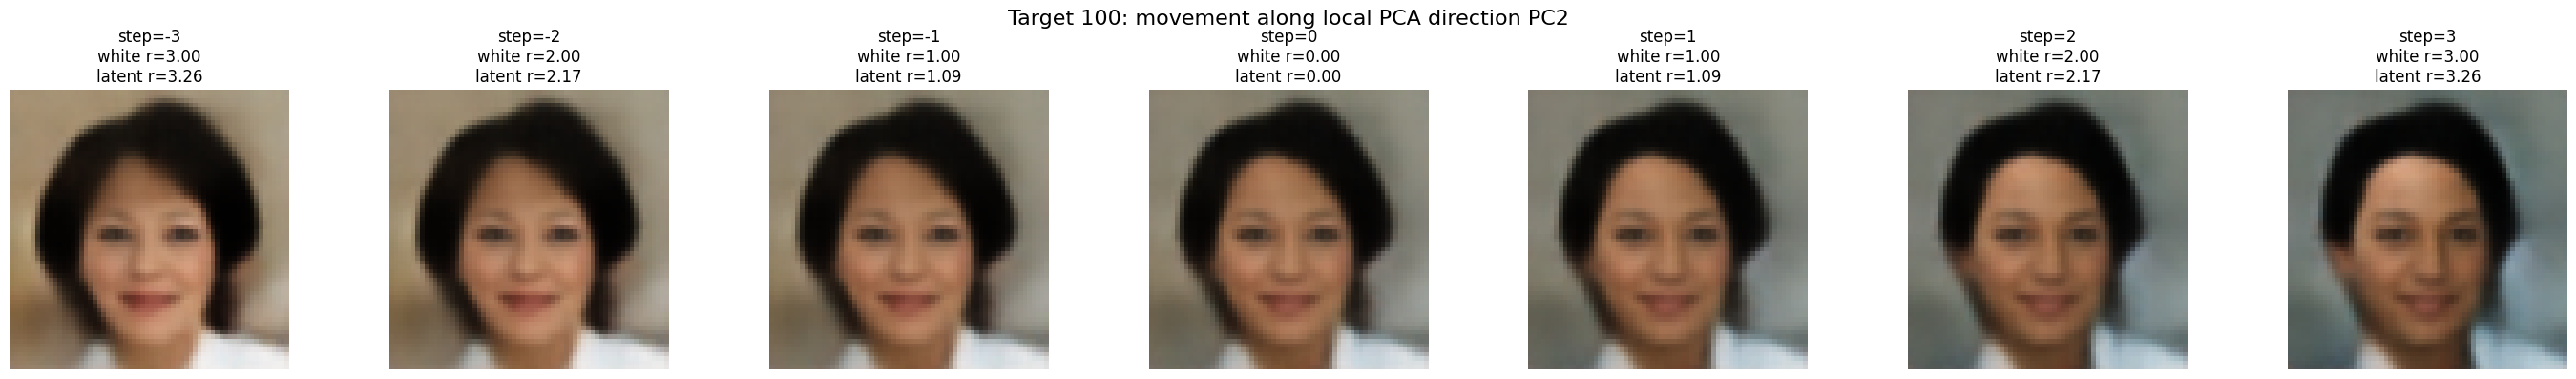

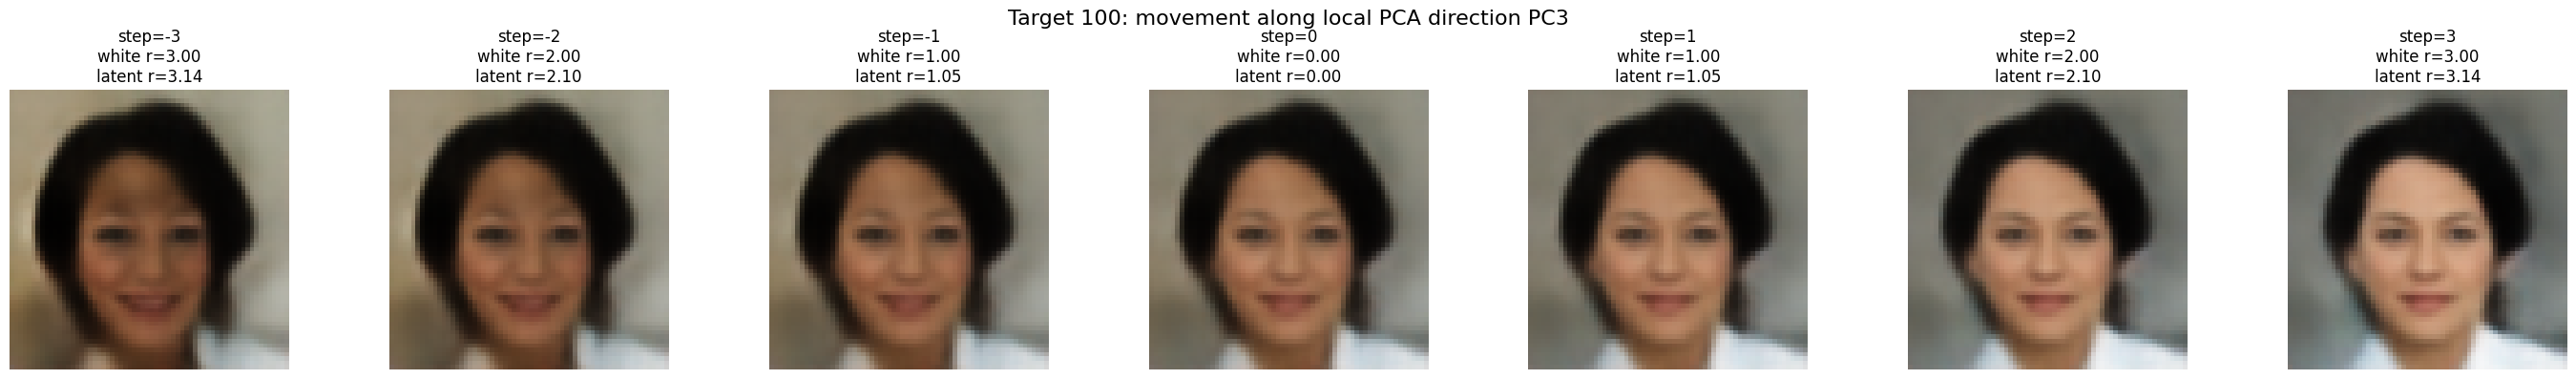

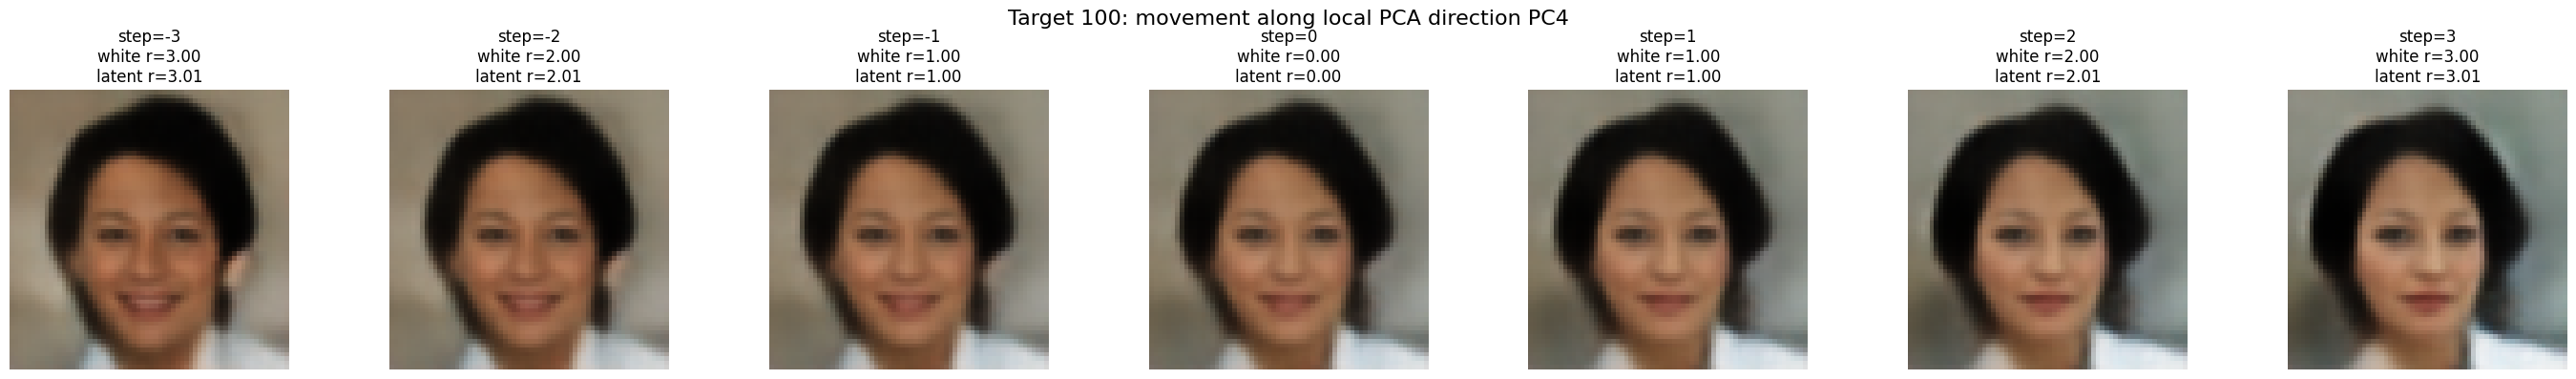

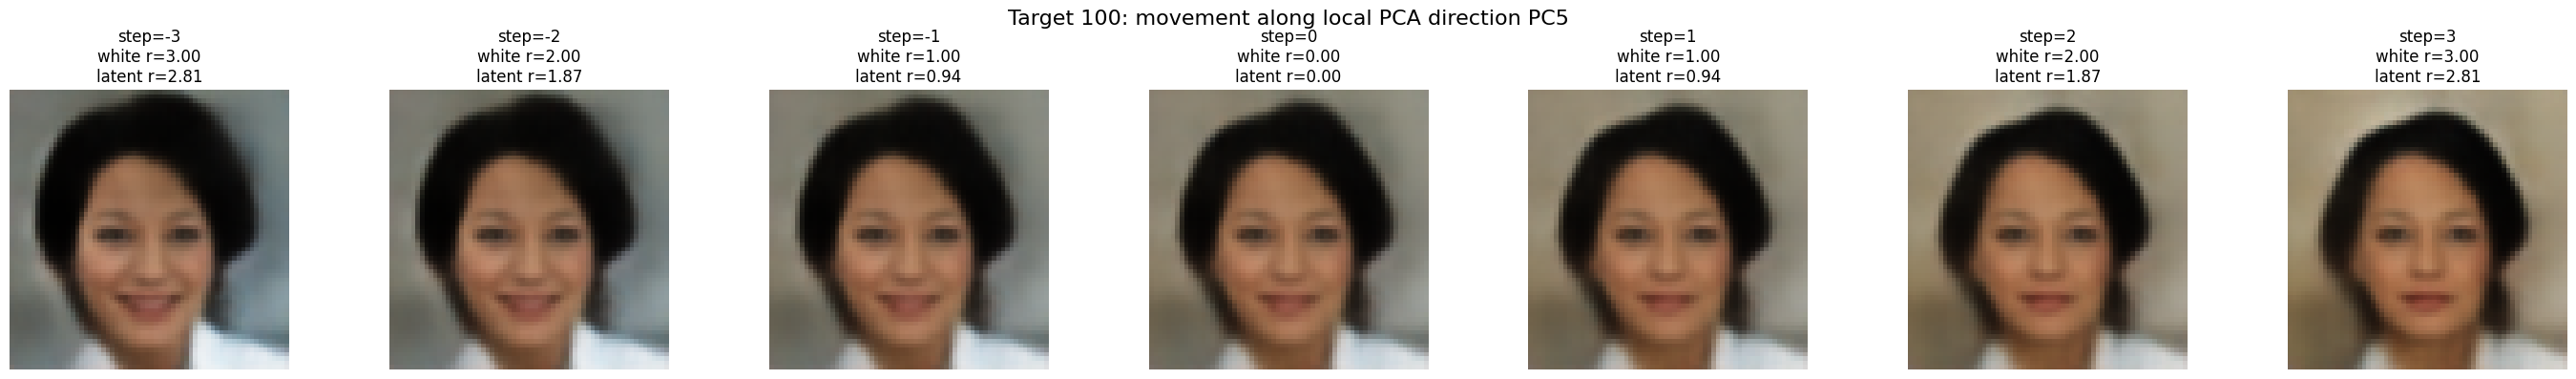

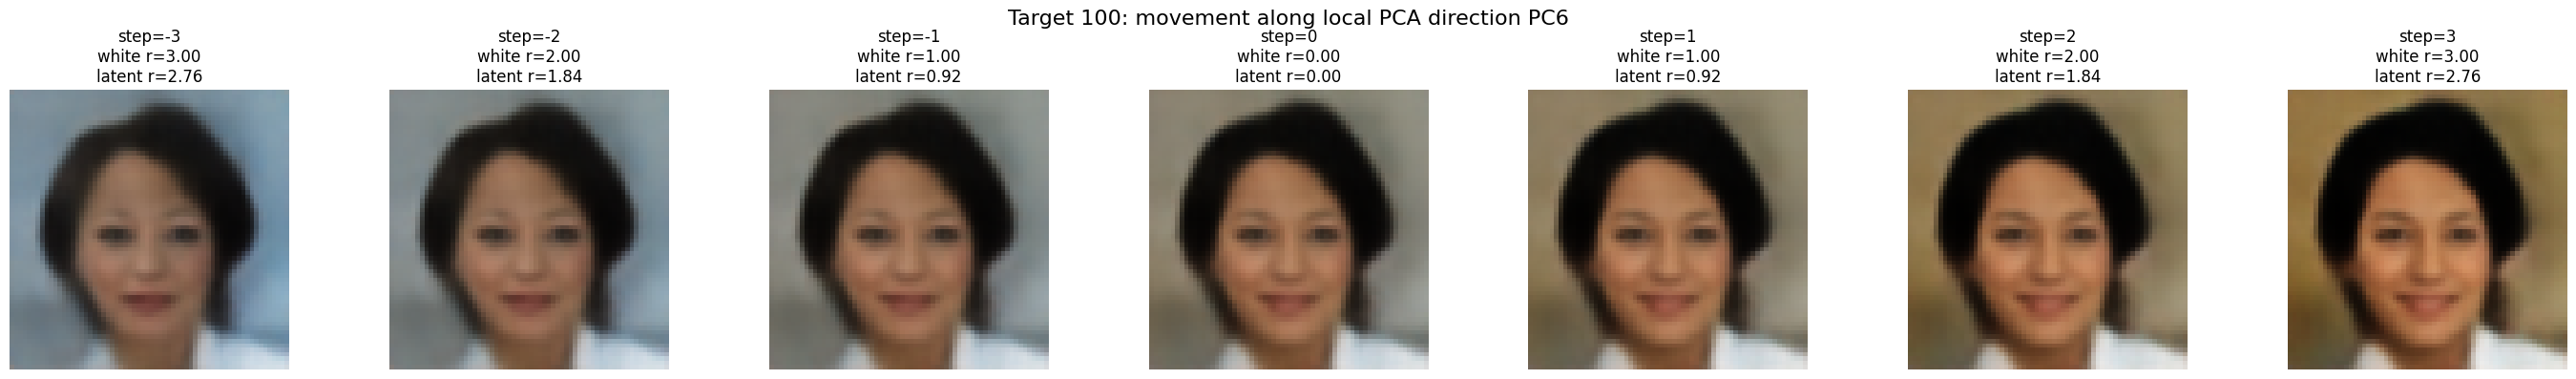

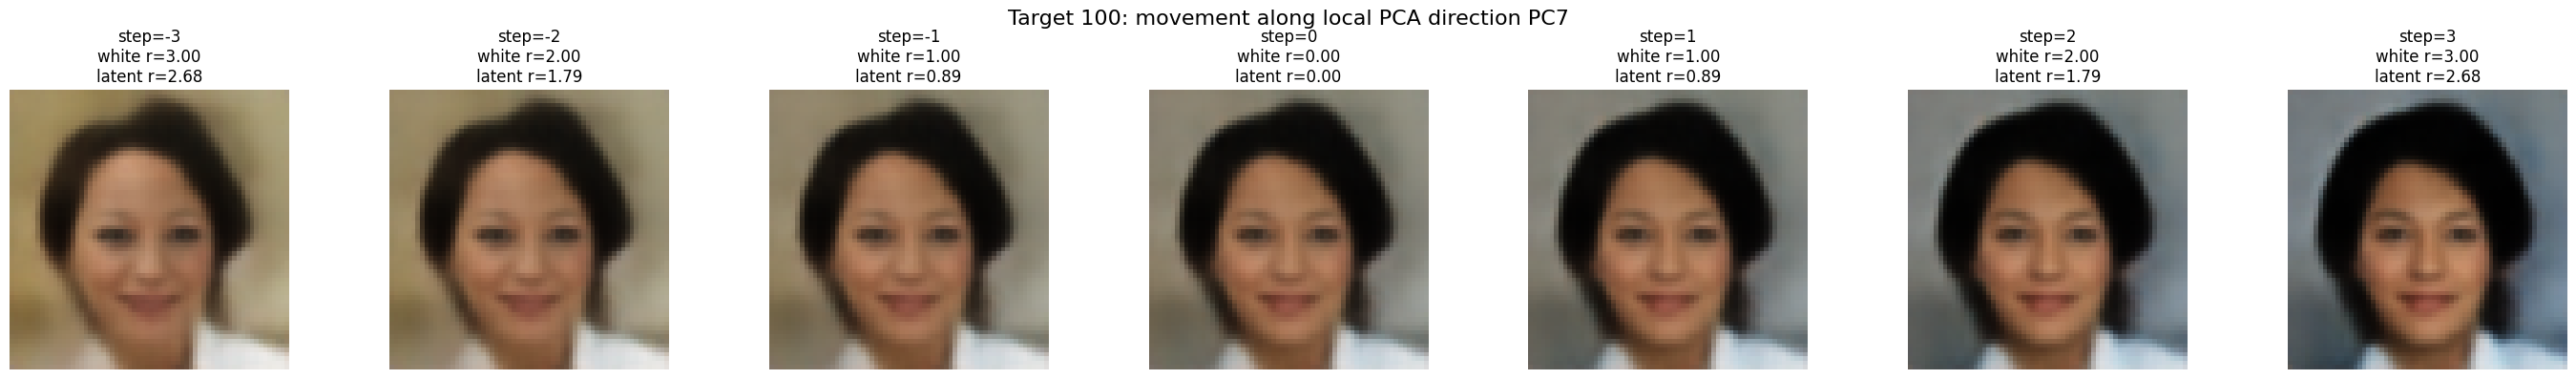

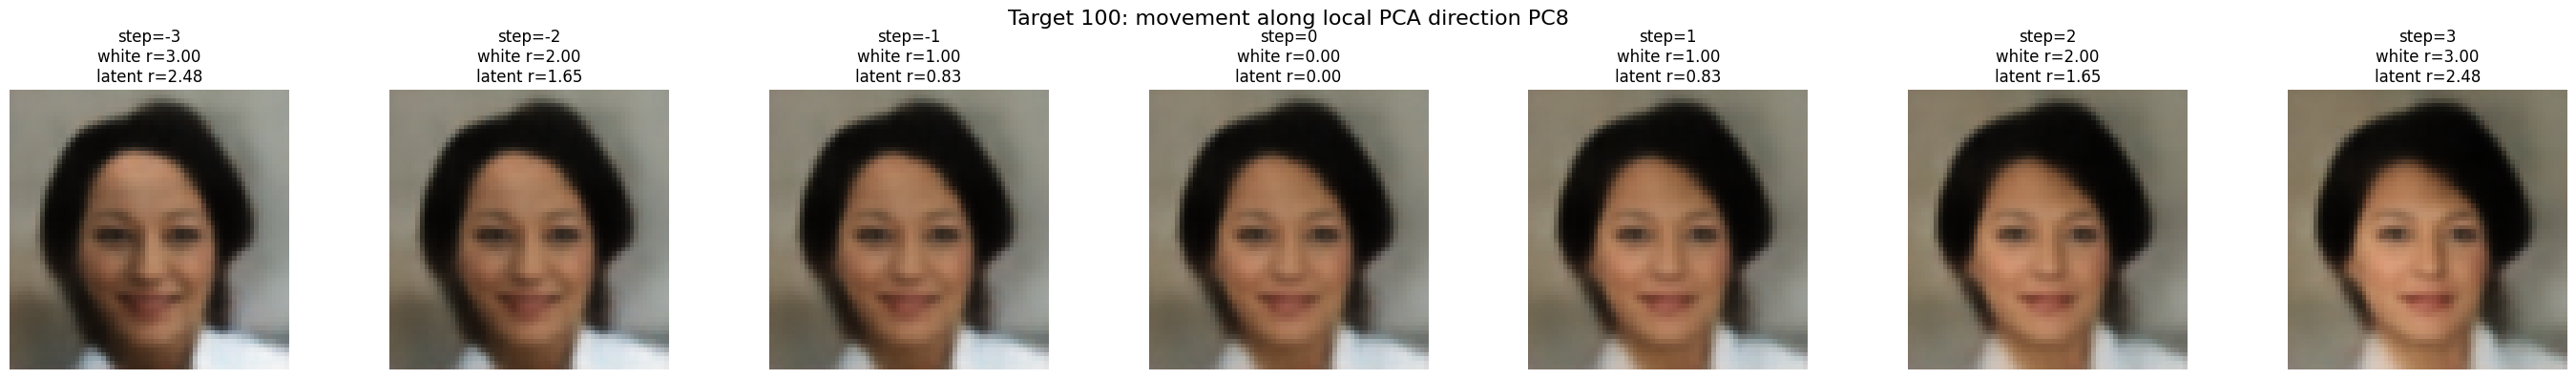

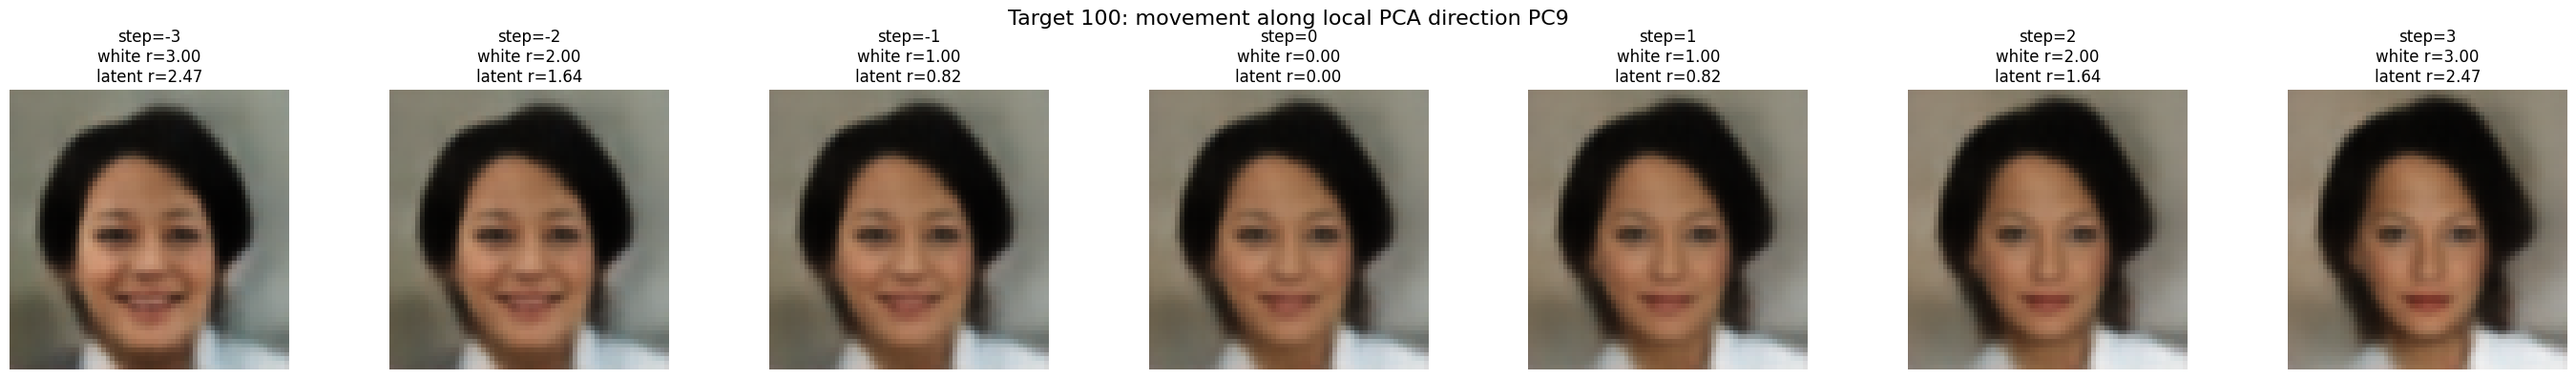

In [18]:
for pc_id in pcs_to_analyze:
    fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 4))

    for col, step in enumerate(steps):

        # from target in whitened PCA coordinates
        X_single = X_whitened.copy()

        # Move only along one PCA coordinate
        X_single[pc_id] += step

        # Convert back to original latent space
        Z_single = unwhiten_local_pca(
            X_single,
            mean_local_n,
            Vt,
            ev
        )

        # Decode image
        img_single = decode_z_to_img(Z_single)

        # Radii
        white_radius = np.linalg.norm(X_single - X_whitened)
        latent_radius = np.linalg.norm(Z_single - X_orig_flat)

        axes[col].imshow(img_single)
        axes[col].axis("off")
        axes[col].set_title(
            f"step={step}\nwhite r={white_radius:.2f}\nlatent r={latent_radius:.2f}"
        )

    fig.suptitle(
        f"Target {target_idx}: movement along local PCA direction PC{pc_id}",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()